In [1]:
import subprocess
import sys

COLAB = "google.colab" in sys.modules


def _install(package):
    if COLAB:
        ans = input(f"Install { package }? [y/n]:")
        if ans.lower() in ["y", "yes"]:
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", "--quiet", package]
            )
            print(f"{ package } installed!")


def _colab_install_missing_deps(deps):
    import importlib

    for dep in deps:
        if importlib.util.find_spec(dep) is None:
            if dep == "iris":
                dep = "scitools-iris"
            _install(dep)


deps = ["pyobis", "joblib"]
_colab_install_missing_deps(deps)

# Investigating PACE and OBIS as a data source for chlorophyll


Created: 2026-08-25


The Plankton, Aerosol, Cloud, ocean Ecosystem (PACE) and the Ocean Biodiversity Information System (OBIS) both provide chlorophyll data on a global scale. The formar will have a much higher global coverage while the former will certainly be more accurate in its data. While researches can ue one to calibrate the other or mix-and-match these data to create a better final product, we wonder how easy it is to fetch them and display on a common grid.

We will use the `pyobis` and `earthaccess` libraries. Earthaccess requires a login to get download access the data. Please navigate to https://earthaccess.readthedocs.io/en/latest/user/ and follow the instructions there on how to create one.

In [2]:
import earthaccess

auth = earthaccess.login(persist=True)

We can not define our search bounding box, time span, and filter for the 1 degree dataset only, the 4 km results will also be fetched. Because it can be a lot of data, we will avoid the 4km high resolution for now with a simple filter to the results and get only the files that end with `1deg.nc` string.

In [3]:
results = earthaccess.search_data(
    short_name="PACE_OCI_L3M_CHL",
    temporal=("2025-01-01", "2025-12-31"),
    bounding_box=(-90.0, 40.0, -75.0, 47.0),
)

fileset = earthaccess.open(results)
one_degree = [f for f in fileset if f.full_name.endswith("1deg.nc")]

The next loop downloads and save the data. We will re-download the data if we do not have it already. The local cache will save us some time and ensure we always have the data even if the server is down.

Local caching is always a good practice to preserver the data and avoid putting a lot of strain on servers with multiple identical requests.

In [4]:
from pathlib import Path

import pandas as pd
import xarray as xr

fname = "chlor_a.nc"

if not Path(fname).exists():

    def fake_time(ds):
        time = ds.attrs["product_name"].split(".")[1].split("_")
        time = pd.to_datetime(time).mean()
        ds = ds.assign_coords(time=time)
        return ds["chlor_a"].expand_dims(time=1)

    ds = xr.open_mfdataset(one_degree, preprocess=fake_time)
    chlor_a = ds["chlor_a"].where(
        (ds["chlor_a"] < ds["chlor_a"].display_max)
        & (ds["chlor_a"] > ds["chlor_a"].display_min)
    )

    chlor_a = chlor_a.mean(dim="time").compute()
else:
    chlor_a = xr.open_dataset(fname)


# DataArray for the chlor_a variable only.
chlor_a = chlor_a["chlor_a"]

Now we can query the OBIS equivalent for phytoplankton. We are testing some generic phytoplankton groupings that should represent most of the chlorophyll:

term | WoRMS | OBIS Map
-----|-------|---------
Diatoms (Bacillariophyceae) | https://www.marinespecies.org/aphia.php?p=taxdetails&id=148899 | https://mapper.obis.org/?taxonid=148899
Dinoflagellates (Dinophyceae) | https://www.marinespecies.org/aphia.php?p=taxdetails&id=19542 | https://mapper.obis.org/?taxonid=19542
Cyanobacteria (Blue-green algae) | https://www.marinespecies.org/aphia.php?p=taxdetails&id=146537 | https://mapper.obis.org/?taxonid=146537
Coccolithophyceae | https://www.marinespecies.org/aphia.php?p=taxdetails&id=592906 | https://mapper.obis.org/?taxonid=592906

In [4]:
from pyobis import occurrences


# IDs from the table above.
aphia_ids = ["148899", "19542", "146537", "592906"]

query = occurrences.search(taxonid=aphia_ids, size=100)
data = query.execute()

data

2026-08-18 11:11:12 - pyobis.cache.cache - INFO - Cache initialized at /home/filipe/.cache/pyobis
2026-08-18 11:11:16 - pyobis.obisutils - INFO - 100 to be fetched. Estimated time =3.85319271683692932 seconds
2026-08-18 11:11:16 - pyobis.obisutils - INFO - Fetching: [████████████████████████████████████████████████████████████████████████████████████████████████████] 100/100
2026-08-18 11:11:16 - pyobis.cache.cache - INFO - Cache initialized at /home/filipe/.cache/pyobis
2026-08-18 11:11:19 - pyobis.obisutils - INFO - Fetched 100 records.


,basisOfRecord,bibliographicCitation,brackish,catalogNumber,class,classid,collectionCode,coordinateUncertaintyInMeters,country,date_end,...,fieldNotes,preparations,verbatimLocality,associatedOccurrences,eventType,identificationVerificationStatus,identificationQualifier,individualCount,forma,formaid
0,MaterialSample,"Brown, M. V. et al. Continental scale monitori...",True,102.100.100/35552-EF9455B8FFF22EFC18B3DCB74655...,Coccolithophyceae,592906.0,BioPlatforms Marine microbes NRS ROT,50.0,Australia,1.498349e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HumanObservation,Continuous Plankton Recorder (CPR) data from t...,True,23AC-43-172,Bacillariophyceae,148899.0,CPR,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MaterialSample,"Focardi, Amaranta,Ostrowski, Martin,Goossen, K...",True,102.100.100/35991-3012DC434CD10C331A5B06F1EAFB...,Dinophyceae,19542.0,BioPlatforms Marine microbes in2016_v04,50.0,Australia,1.473984e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MATERIAL_SAMPLE,NaN,True,NaN,Dinophyceae,19542.0,NaN,NaN,NaN,1.676419e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MATERIAL_SAMPLE,NaN,True,NaN,Dinophyceae,19542.0,NaN,NaN,NaN,1.447891e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Occurrence,NaN,True,d2ec2d5e06a7683d488c60683531_ARVAM_60683531_AR...,Dinophyceae,19542.0,QUADRIGE - Coastal monitoring database and pro...,NaN,NaN,1.521072e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,MATERIAL_SAMPLE,NaN,True,NaN,Dinophyceae,19542.0,NaN,NaN,NaN,1.558138e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,MATERIAL_SAMPLE,NaN,True,NaN,Cyanophyceae,146542.0,NaN,NaN,NaN,1.475712e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,MaterialSample,"Brown, M. V. et al. Continental scale monitori...",True,102.100.100/34175-9BDF23CB027253367726EAD57B18...,Coccolithophyceae,592906.0,BioPlatforms Marine microbes NRS ROT,50.0,Australia,1.458691e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The next step is top query for gridded occurrence data for the `aphia_ids` we selected above.

In [5]:
features = occurrences.grid(3, taxonid=aphia_ids).execute()

2026-08-18 11:11:19 - pyobis.cache.cache - INFO - Cache initialized at /home/filipe/.cache/pyobis
2026-08-18 11:11:22 - pyobis.cache.cache - INFO - Cache initialized at /home/filipe/.cache/pyobis


And convert to geodataframe to visualize to match with the PACE data later.

In [6]:
import geopandas as gpd

gdf = gpd.GeoDataFrame.from_features(features)
gdf

,geometry,n
0,"POLYGON ((150.46875 -35.15625, 151.875 -35.156...",1517546
1,"POLYGON ((153.28125 -28.125, 154.6875 -28.125,...",1090666
2,"POLYGON ((147.65625 -43.59375, 149.0625 -43.59...",980360
3,"POLYGON ((115.3125 -32.34375, 116.71875 -32.34...",911524
4,"POLYGON ((146.25 -19.6875, 147.65625 -19.6875,...",831335
...,...,...
8994,"POLYGON ((-150.46875 -70.3125, -149.0625 -70.3...",1
8995,"POLYGON ((-146.25 -87.1875, -144.84375 -87.187...",1
8996,"POLYGON ((-167.34375 -78.75, -165.9375 -78.75,...",1
8997,"POLYGON ((-178.59375 -73.125, -177.1875 -73.12...",1


Note that the occurence rages from 1 to vwry large numbers (`~10e6`). We need to log-normalize the colors for better visualization. After that, we can plot the two side.

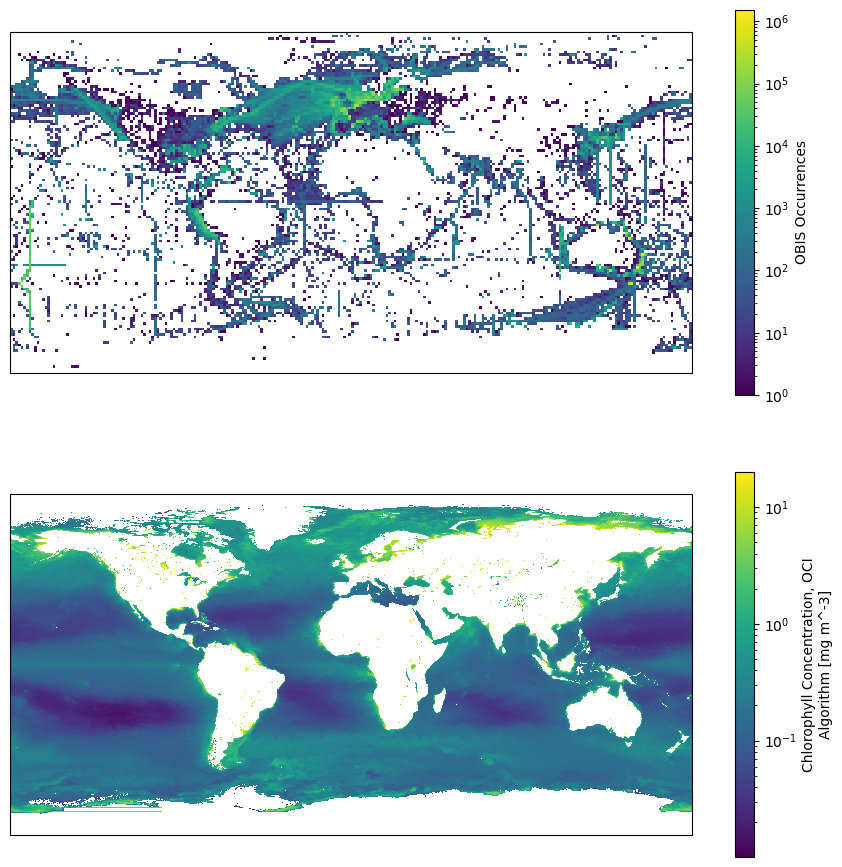

In [7]:
import cartopy.crs as ccrs
import matplotlib.colors as colors
import matplotlib.pyplot as plt

norm = colors.LogNorm()

projection = ccrs.PlateCarree()
fig, (ax0, ax1) = plt.subplots(
    nrows=2,
    subplot_kw={"projection": projection},
    sharex=True,
    sharey=True,
    figsize=(11, 11),
)

ax = gdf.plot(
    column="n",
    norm=colors.LogNorm(),
    legend=True,
    legend_kwds={"label": "OBIS Occurrences"},
    ax=ax0,
)


cs = chlor_a.plot(norm=colors.LogNorm(), ax=ax1)

We can see some features, like a higher density near the coast, currents, and the oligotrophic areas at the gyres centers. As expected, OBIS data density falls off quickly outside of the North Atlantic. However, there is a clear "Gulf Stream signal" in the dataset that is absent in the PACE data. We can envison some sorte of interpolation that will use the OBIS data to increase precision and PACE to augument the spatial resolution.

We won't be doing any of that here though. Our goal is to demostrate how to fetch mathing data and display them side-by-side. In order to test a better "qualitative" way to compare the data we will average out the PACE data to the OBIS occurrences geometry, and put the data on an hexagonal hierarchical geospatial indexing system (H3) for plotting and comparing each hexagon.

In [8]:
def average_chlor_a(geom):
    xmin, ymin, xmax, ymax = geom

    c = chlor_a.where(
        (xmin <= chlor_a["lon"])
        & (chlor_a["lon"] <= xmax)
        & (ymin <= chlor_a["lat"])
        & (chlor_a["lat"] <= ymax),
        drop=True,
    )
    return float(c.mean().to_numpy())

We will use joblib's `Parallel` to speed up the averages.

In [9]:
import multiprocessing

from joblib import Parallel, delayed

num_cores = multiprocessing.cpu_count()

bounds = gdf["geometry"].bounds.to_numpy()

chlor_avg = Parallel(n_jobs=num_cores)(
    delayed(average_chlor_a)(geom) for geom in bounds
)

gdf["chlor_avg"] = chlor_avg

Now make the H3 index for both datasets.

In [10]:
import h3pandas  # noqa I001

gdf["x"] = gdf["geometry"].centroid.x
gdf["y"] = gdf["geometry"].centroid.y

# The resolution goes from 0-15, using 2 b/c that is the closest to the OBIS squares.
resolution = 2

df = gdf[["x", "y", "n", "chlor_avg"]]

dfh3 = df.h3.geo_to_h3(
    resolution=resolution,
    lat_col="y",
    lng_col="x",
    set_index=True,
)


dfh3 = dfh3.drop(columns=["x", "y"]).groupby(dfh3.index.name).sum()
gdfh3 = dfh3.h3.h3_to_geo_boundary()

We need to correct the longitudes for better plotting at the dateline.

In [11]:
import numpy as np


def fix_geom(geom):
    from shapely import Polygon

    lons, lats = map(list, geom.boundary.coords.xy)
    if max(abs(np.diff(lons))) > 180:
        xx = [x + 360 if x < 0 else x for x in lons]
        return Polygon(zip(xx, lats))
    else:
        return geom


gdfh3["geometry"] = gdfh3["geometry"].apply(fix_geom)
gdfh3["log_n"] = np.log(gdfh3["n"])

In [12]:
gdfh3

,n,chlor_avg,geometry,log_n
h3_02,,,,
820007fffffffff,667,2.514208,"POLYGON ((36.42872 77.68575, 43.86177 78.00915...",6.502790
82000ffffffffff,1891,3.735855,"POLYGON ((30.78838 80.33975, 40.19373 80.81642...",7.544861
820017fffffffff,119,1.853077,"POLYGON ((48.58085 76.68007, 55.65377 76.66744...",4.779123
82001ffffffffff,1085,3.568005,"POLYGON ((46.68072 79.52276, 55.75077 79.55833...",6.989335
820027fffffffff,2371,6.709328,"POLYGON ((29.20747 75.65094, 35.20921 76.15221...",7.771067
...,...,...,...,...
82f31ffffffffff,9,5.836377,"POLYGON ((-168.19092 -76.36649, -170.0979 -77....",2.197225
82f337fffffffff,71,1.949622,"POLYGON ((180.32561 -73.31022, 177.7638 -74.58...",4.262680
82f367fffffffff,1,0.113506,"POLYGON ((-151.74413 -69.84475, -151.56695 -71...",0.000000


Last but not least, to make it easier to spot patterns, let's make all the data between 0-1 so we can easily see any patterns that matches on both sources.

In [13]:
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())


gdfh3["n_norm"] = normalize(gdfh3["log_n"])
gdfh3["chlor_norm"] = normalize(gdfh3["chlor_avg"])

The obis data at the top and pace at the lower panel.

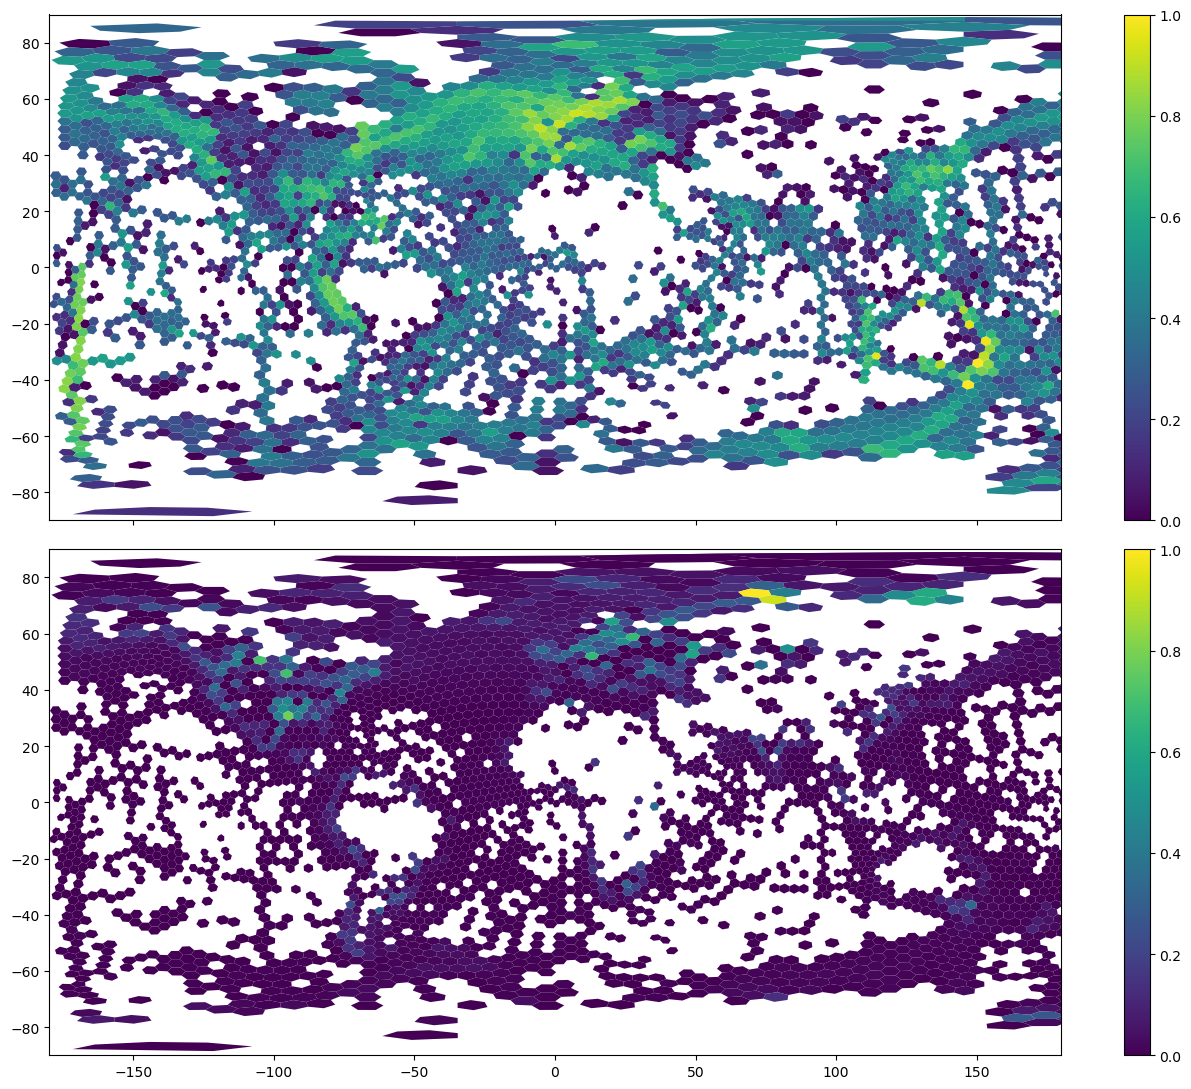

In [14]:
fig, (ax0, ax1) = plt.subplots(nrows=2, figsize=(13, 11), sharex=True, sharey=True)

ax = gdfh3.plot(column="n_norm", ax=ax0, legend=True)
gdfh3.plot(column="chlor_norm", ax=ax1, legend=True)
ax0.axis([-180, 180, -90, 90])
fig.tight_layout()

Done! Hopefully this example will be useful for those using these different data sources.